In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch_geometric.nn import MessagePassing,  global_add_pool
from torch_geometric.data import Data, DataLoader

b = np.load('md17_benzene.npz')
print(b.files)

all_coords = b['coords']
all_energies = b['energies']

N = len(all_coords) 
perm = np.random.permutation(N)

coords = all_coords[perm[:2000]]    
energies = all_energies[perm[:2000]]

c:\Users\home\OneDrive\Documents\Python Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['nuclear_charges', 'coords', 'energies', 'forces', 'old_indices', 'old_energies', 'old_forces']


In [2]:
def bonds(coords):
    N = coords.shape[0]
    A = coords.shape[1]
    distances = []
    edge_indices = []
    vectors = []
    for m in range(N):
        dist_m = []
        edge_index_m = []
        vectors_m = []
        for j in range(A):
            for k in range(A):
                if j!=k:
                    v = coords[m,j,:]-coords[m,k,:]
                    d = torch.linalg.norm(v)
                    if d < 3.3:
                        dist_m.append(d)
                        edge_index_m.append([k,j])
                        vectors_m.append(v)

        distances.append(dist_m)
        edge_indices.append(edge_index_m)
        vectors.append(vectors_m)

    return distances, edge_indices, vectors

In [3]:
def rbf(distances):
    tot_rbfs = []
    mu = torch.linspace(0.0,3.3,32)
    gamma = 1.0/((mu[1]-mu[0])*(mu[1]-mu[0]))
    for dist_m in distances:
        rbfs_m = []
        for i in range(len(dist_m)):
            rbfs_edge = []
            for j in range(len(mu)):
                phi = torch.exp(-gamma*(dist_m[i]-mu[j])*(dist_m[i]-mu[j]))
                rbfs_edge.append(phi)
            rbfs_m.append(rbfs_edge)

        rbfs_m = torch.tensor(rbfs_m, dtype=torch.float32)
        tot_rbfs.append(rbfs_m)

    return tot_rbfs

In [4]:
def angles(distances, edge_indices, vectors):

    all_angles = []
    all_pairs = []

    N = len(distances)

    for m in range(N):

        dist_m = distances[m]
        edge_m = edge_indices[m]
        vec_m = vectors[m]

        i = [edge[1] for edge in edge_m]
        E = len(dist_m)
        angles_m = []
        pairs_m = []

        for j in range(E):
            for k in range(j+1,E):
                if i[j]==i[k]:
                    x = torch.dot(vec_m[j],vec_m[k])/(dist_m[j]*dist_m[k])
                    theta = torch.acos(x)
                    angles_m.append(theta)
                    pairs_m.append((j,k))

        all_angles.append(angles_m)
        all_pairs.append(pairs_m)

    return all_angles, all_pairs

In [5]:
def sbf(all_angles):

    all_sbfs = []
    for angles_m in all_angles:
        sbfs_m = []
        for angle in angles_m:
            P0 = torch.tensor(1.0)
            P1 = torch.cos(angle)
            Polyn = []
            Polyn.append(P1)
            for l in range(2,33):
                Pl = ((2*l-1)*(torch.cos(angle))*P1 - (l-1)*P0)/l
                P0 = P1
                P1 = Pl
                Polyn.append(Pl)

            sbfs_m.append(torch.stack(Polyn))

        all_sbfs.append(torch.stack(sbfs_m))

    return all_sbfs

In [6]:
distances, edge_indices, vectors = bonds(torch.from_numpy(coords))
rbf_features = rbf(distances)
angles, angle_pairs = angles(distances, edge_indices, vectors)
sbf_features = sbf(angles)

In [7]:
def concatenation(rbf_features, sbf_features, angles_pairs):
    all_features = []
    N = len(rbf_features)

    for m in range(N):
        pairs_m = angles_pairs[m]
        rbf_features_m = rbf_features[m]
        sbf_features_m = sbf_features[m]
        reshape = torch.zeros_like(rbf_features_m)
        for k, (i,j) in enumerate(pairs_m):
            reshape[i] += sbf_features_m[k]
            reshape[j] += sbf_features_m[k]

        features_m = torch.cat((rbf_features_m, reshape), dim=1)
        all_features.append(features_m)

    return all_features

In [8]:
all_features = concatenation(rbf_features, sbf_features, angle_pairs)

In [9]:
def pyg_data(m, edge_indices, all_features, energies):
    z = torch.tensor(b['nuclear_charges'], dtype=torch.long)
    edge_index = torch.tensor(edge_indices[m], dtype=torch.long).t().contiguous()
    edge_attr = all_features[m]
    y = torch.tensor([energies[m]], dtype=torch.float32)
    data = Data(z=z, edge_index=edge_index, edge_attr=edge_attr, y=y)
    return data

In [10]:
full_data = []
N = coords.shape[0]
for m in range(N):
    data = pyg_data(m, edge_indices, all_features, energies)
    full_data.append(data)

In [11]:
train_data, test_data = train_test_split(full_data, test_size=0.2)

train_energies = torch.stack([data.y for data in train_data])
energy_mean = train_energies.mean()
energy_std = train_energies.std()

for data in train_data:
    data.y = (data.y - energy_mean)/energy_std

for data in test_data:
    data.y = (data.y - energy_mean)/energy_std

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

C:\Users\home\AppData\Local\Temp\ipykernel_32144\3450336400.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
C:\Users\home\AppData\Local\Temp\ipykernel_32144\3450336400.py:14: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_data, batch_size=32, shuffle=False)


In [12]:
class MessagePassingLayer(nn.Module):
    def __init__(self, input_features=32, hidden1=32, feat_dim=64, hidden_edge1=64, hidden2=32, hidden3=32):
        super().__init__()

        self.atom_wise1 = nn.Linear(input_features, hidden1)

        self.bond_wise1 = nn.Linear(feat_dim, hidden_edge1)
        self.act1 = nn.SiLU()
        self.bond_wise2 = nn.Linear(hidden_edge1, hidden1)
        self.act2 = nn.SiLU()

        self.atom_wise2 = nn.Linear(hidden1, hidden2)
        self.act3 = nn.SiLU()
        self.atom_wise3 = nn.Linear(hidden2, hidden3)

        #self.dropout = nn.Dropout(p=0.1)


    def forward(self, x, edge_index, edge_attr):

        j = edge_index[0]
        i = edge_index[1]

        xj = x[j]
        xj_prime = self.atom_wise1(xj)

        h1 = self.bond_wise1(edge_attr)
        h2 = self.act1(h1)
        h3 = self.bond_wise2(h2)
        h4 = self.act2(h3)

        messages = xj_prime * h4

        xi_prime = torch.zeros_like(x)
        xi_prime.index_add_(0, i, messages)

        xi_prime2 = self.atom_wise2(xi_prime)
        xi_prime3 = self.act3(xi_prime2)
        #xi_prime3 = self.dropout(xi_prime3)
        xi_prime4 = self.atom_wise3(xi_prime3)

        x_new = x + xi_prime4

        return x_new

In [13]:
class GNN(nn.Module):
    def __init__(self, input_features=32, hidden1=32, feat_dim=64, hidden_edge1=64, hidden2=32, hidden3=32, hidden4=16, output_feature=1):
        super().__init__()

        self.embedding = nn.Embedding(7, input_features)

        self.mp1 = MessagePassingLayer(input_features, hidden1, feat_dim, hidden_edge1, hidden2, hidden3)
        self.mp2 = MessagePassingLayer(input_features, hidden1, feat_dim, hidden_edge1, hidden2, hidden3)
        self.mp3 = MessagePassingLayer(input_features, hidden1, feat_dim, hidden_edge1, hidden2, hidden3)

        self.dropout = nn.Dropout(p=0.1)

        self.readout1 = nn.Linear(hidden3, hidden4)
        self.act = nn.SiLU()
        self.readout2 = nn.Linear(hidden4, output_feature)

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.z, data.edge_index, data.edge_attr, data.batch

        x = self.embedding(x)

        x = self.mp1(x, edge_index, edge_attr)
        x = self.mp2(x, edge_index, edge_attr)
        x = self.mp3(x, edge_index, edge_attr)

        x = self.dropout(x)

        x = self.readout1(x)
        x = self.act(x)
        x = self.readout2(x)

        x = global_add_pool(x, batch)

        return x.squeeze(-1) #(32, 1) -> (32,)

In [14]:
model = GNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses = []

epochs = 200
for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        pred = model(batch)
        loss = F.mse_loss(pred, batch.y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * batch.num_graphs

    avg_train_loss = total_train_loss / len(train_data)
    train_losses.append(avg_train_loss)
    print(f'Epoch {epoch} loss: {avg_train_loss:.4f}')

c:\Users\home\OneDrive\Documents\Python Projects\.venv\Lib\site-packages\torch_geometric\data\data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_attr', 'y', 'edge_index', 'z'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  return sum([v.num_nodes for v in self.node_stores])
c:\Users\home\OneDrive\Documents\Python Projects\.venv\Lib\site-packages\torch_geometric\data\collate.py:142: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_attr', 'y', 'edge_index', 'z'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  repeats = [store.num_nodes or 0 for store in stores]


Epoch 0 loss: 1.3933
Epoch 1 loss: 1.0008
Epoch 2 loss: 0.7067
Epoch 3 loss: 0.6232
Epoch 4 loss: 0.5232
Epoch 5 loss: 0.5158
Epoch 6 loss: 0.4777
Epoch 7 loss: 0.4694
Epoch 8 loss: 0.4305
Epoch 9 loss: 0.4269
Epoch 10 loss: 0.3884
Epoch 11 loss: 0.4266
Epoch 12 loss: 0.3800
Epoch 13 loss: 0.3460
Epoch 14 loss: 0.3107
Epoch 15 loss: 0.2855
Epoch 16 loss: 0.2305
Epoch 17 loss: 0.2914
Epoch 18 loss: 0.1954
Epoch 19 loss: 0.1755
Epoch 20 loss: 0.1801
Epoch 21 loss: 0.1509
Epoch 22 loss: 0.1283
Epoch 23 loss: 0.1417
Epoch 24 loss: 0.1164
Epoch 25 loss: 0.1203
Epoch 26 loss: 0.0961
Epoch 27 loss: 0.0951
Epoch 28 loss: 0.1091
Epoch 29 loss: 0.1048
Epoch 30 loss: 0.0836
Epoch 31 loss: 0.1094
Epoch 32 loss: 0.0844
Epoch 33 loss: 0.0886
Epoch 34 loss: 0.0720
Epoch 35 loss: 0.0620
Epoch 36 loss: 0.0599
Epoch 37 loss: 0.0724
Epoch 38 loss: 0.0540
Epoch 39 loss: 0.0758
Epoch 40 loss: 0.0529
Epoch 41 loss: 0.0549
Epoch 42 loss: 0.0782
Epoch 43 loss: 0.0641
Epoch 44 loss: 0.0555
Epoch 45 loss: 0.054

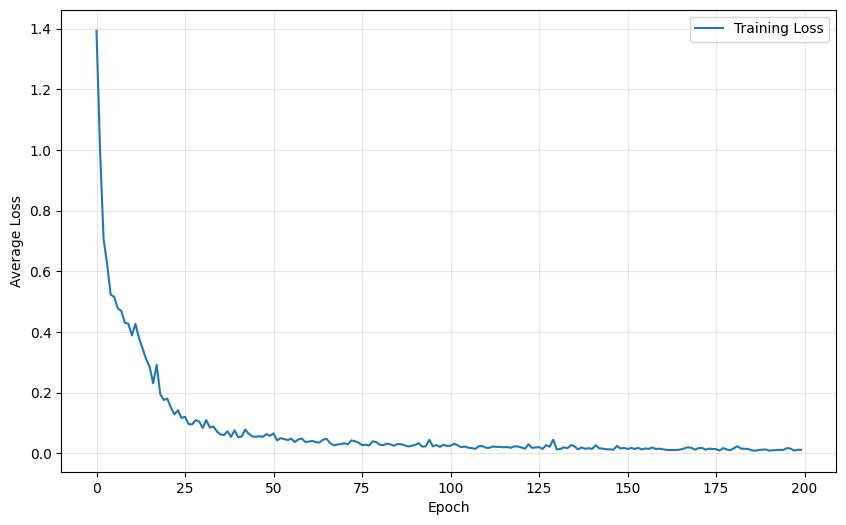

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
predicted_energy = []
target_energy = []

with torch.no_grad():
    total_test_loss = 0
    N = len(test_data)
    for batch in test_loader:
        model.eval()
        pred = model(batch)
        predicted_energy.append(pred)
        target_energy.append(batch.y)
        test_loss = F.mse_loss(pred, batch.y)
        total_test_loss += test_loss.item() * batch.num_graphs
    
    avg_test_loss = total_test_loss / N
    print(f"Final Test Loss: {avg_test_loss:.4f}")


predicted_energy = torch.cat(predicted_energy).numpy()
target_energy = torch.cat(target_energy).numpy()


Final Test Loss: 0.0101


c:\Users\home\OneDrive\Documents\Python Projects\.venv\Lib\site-packages\torch_geometric\data\data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_attr', 'y', 'edge_index', 'z'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  return sum([v.num_nodes for v in self.node_stores])
c:\Users\home\OneDrive\Documents\Python Projects\.venv\Lib\site-packages\torch_geometric\data\collate.py:142: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_attr', 'y', 'edge_index', 'z'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  repeats = [store.num_nodes or 0 for store in stores]


In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(target_energy, predicted_energy)
mae = mean_absolute_error(target_energy, predicted_energy)
mse = mean_squared_error(target_energy, predicted_energy)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")        
print(f"MAE: {mae:.4f}")            
print(f"RMSE: {rmse:.4f}")

R² Score: 0.9895
MAE: 0.0704
RMSE: 0.1007


Average Predicted Energy: -145431.4844
Average Target Energy: -145431.4219


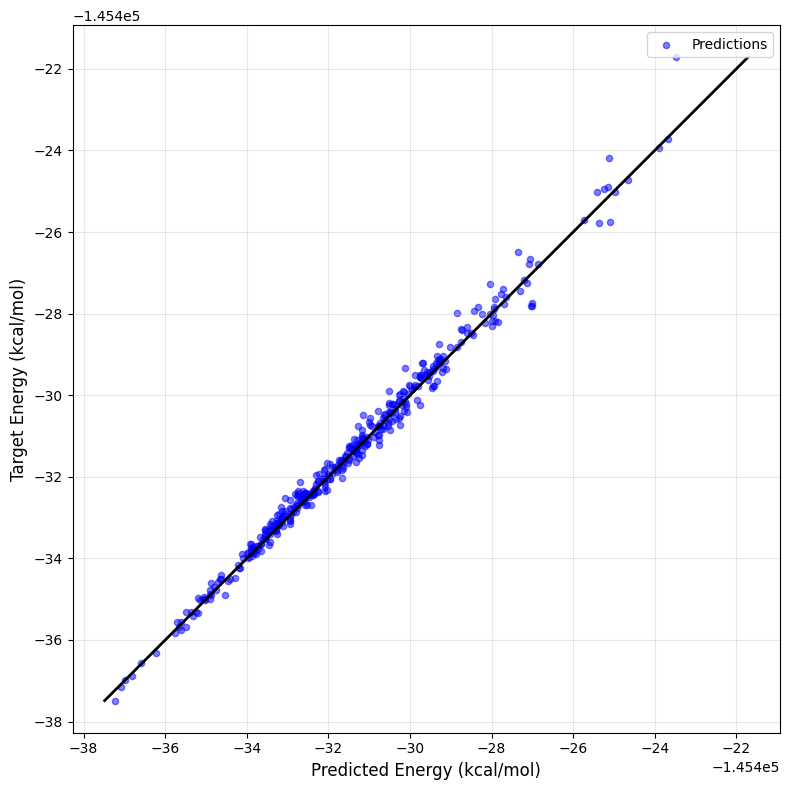

In [27]:
predicted_energy_nn = predicted_energy * energy_std.item() + energy_mean.item()
target_energy_nn = target_energy * energy_std.item() + energy_mean.item()
average_pred = np.mean(predicted_energy_nn)
average_target = np.mean(target_energy_nn)
print(f"Average Predicted Energy: {average_pred:.4f}")
print(f"Average Target Energy: {average_target:.4f}")

plt.figure(figsize=(8,8))
plt.scatter(predicted_energy_nn, target_energy_nn, alpha=0.5, s=20, color='blue', label='Predictions')
plt.plot([target_energy_nn.min(), target_energy_nn.max()], 
         [target_energy_nn.min(), target_energy_nn.max()], 
         'k-', lw=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('Predicted Energy (kcal/mol)', fontsize=12)
plt.ylabel('Target Energy (kcal/mol)', fontsize=12)
plt.tight_layout()
plt.savefig('Target_vs_predE_Benzene.png')
plt.show()

In [25]:
MAE_nn = mean_absolute_error(target_energy_nn, predicted_energy_nn)
MSE_nn = mean_squared_error(target_energy_nn, predicted_energy_nn)
RMSE_nn = np.sqrt(MSE_nn)

print(f"MAE: {MAE_nn:.4f}")  
print(f"RMSE: {RMSE_nn:.4f}")

MAE: 0.1713
RMSE: 0.2447
